In [1]:
import os
import pickle
import tarfile
import datetime
import numpy as np
import urllib.request
import sklearn.metrics
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import zipfile
import tensorboard

IMG_SIZE = (64, 64)
SEED = 42

2026-05-29 16:14:25.683487: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780071265.882569      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780071265.940039      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780071266.366604      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780071266.366644      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780071266.366647      58 computation_placer.cc:177] computation placer alr

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
              tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [3]:
%load_ext tensorboard

In [4]:
BATCH_SIZE = 128
HISTORY_DIR = './history'
os.makedirs(HISTORY_DIR, exist_ok=True)

In [5]:
def download_data():
    if not os.path.exists('tiny-imagenet-200'):
        urllib.request.urlretrieve('http://cs231n.stanford.edu/tiny-imagenet-200.zip', 'tiny-imagenet-200.zip')
        file = zipfile.ZipFile('tiny-imagenet-200.zip', 'r')
        file.extractall()

In [6]:
download_data()

In [1]:
with open('tiny-imagenet-200/wnids.txt') as f:
    wnids = [line.strip() for line in f if line.strip()]

wnid_to_name = {}
with open('tiny-imagenet-200/words.txt', encoding='utf-8') as f:
    for line in f:
        wnid, name = line.rstrip('\n').split('\t', 1)
        if wnid in set(wnids):
            wnid_to_name[wnid] = name

print(f'classes: {len(wnids)}')
print('name:')
for w in wnids:
    print(f'{w}: {wnid_to_name[w]}')

classes: 200
name:
n02124075: Egyptian cat
n04067472: reel
n04540053: volleyball
n04099969: rocking chair, rocker
n07749582: lemon
n01641577: bullfrog, Rana catesbeiana
n02802426: basketball
n09246464: cliff, drop, drop-off
n07920052: espresso
n03970156: plunger, plumber's helper
n03891332: parking meter
n02106662: German shepherd, German shepherd dog, German police dog, alsatian
n03201208: dining table, board
n02279972: monarch, monarch butterfly, milkweed butterfly, Danaus plexippus
n02132136: brown bear, bruin, Ursus arctos
n04146614: school bus
n07873807: pizza, pizza pie
n02364673: guinea pig, Cavia cobaya
n04507155: umbrella
n03854065: organ, pipe organ
n03838899: oboe, hautboy, hautbois
n03733131: maypole
n01443537: goldfish, Carassius auratus
n07875152: potpie
n03544143: hourglass
n09428293: seashore, coast, seacoast, sea-coast
n03085013: computer keyboard, keypad
n02437312: Arabian camel, dromedary, Camelus dromedarius
n07614500: ice cream, icecream
n03804744: nail
n04265275: 

In [8]:
train_dataset = keras.utils.image_dataset_from_directory(
    'tiny-imagenet-200/train',
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)
class_names = train_dataset.class_names
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

Found 100000 files belonging to 200 classes.


I0000 00:00:1780071304.894639      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
def reorganize_val():
    val_dir = 'tiny-imagenet-200/val'
    ann_file = os.path.join(val_dir, 'val_annotations.txt')
    if not os.path.exists(ann_file):
        return 

    with open(ann_file) as f:
        for line in f:
            tags = line.split('\t')
            src = os.path.join(val_dir, 'images', tags[0])
            if os.path.exists(src):
                dst_dir = os.path.join(val_dir, tags[1])
                os.makedirs(dst_dir, exist_ok=True)
                os.rename(src, os.path.join(dst_dir, tags[0]))

    os.rmdir(os.path.join(val_dir, 'images'))
    os.remove(ann_file)

reorganize_val()

In [10]:
val_dataset = keras.utils.image_dataset_from_directory(
    'tiny-imagenet-200/val',
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_names=class_names,
)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

Found 10000 files belonging to 200 classes.


In [11]:
def get_name(prefix: str | None, suffix: str) -> str | None:
    return prefix and f"{prefix}_{suffix}"

In [12]:
def resnet_block(
        x: keras.KerasTensor,
        features: int,
        name: str | None = None,
        strides: int = 1,
    ) -> keras.KerasTensor:

    short = x
    y = keras.layers.Conv2D(features, 3, strides=strides, padding='same', use_bias=False, name=get_name(name, 'conv2d_1'))(x)
    y = keras.layers.BatchNormalization(name=get_name(name, 'norm_1'))(y)
    y = keras.layers.ReLU(name=get_name(name, 'relu_1'))(y)
    y = keras.layers.Conv2D(features, 3, strides=1, padding='same', use_bias=False, name=get_name(name, 'conv2d_2'))(y)
    y = keras.layers.BatchNormalization(name=get_name(name, 'norm_2'))(y)

    if strides != 1 or short.shape[-1] != features:
        short = keras.layers.Conv2D(features, 1, strides=strides, use_bias=False, name=get_name(name, 'conv2d_short'))(short)
        short = keras.layers.BatchNormalization(name=get_name(name, 'norm_short'))(short)

    output = keras.layers.Add(name=get_name(name, 'add'))([y, short])
    output = keras.layers.ReLU(name=get_name(name, 'relu_2'))(output)
    return output


In [13]:
def resnet(
        input_shape=(64, 64, 3),
        num_classes=200,
        n=5,
        name: str | None = None,
    ) -> keras.Model:
    inputs = keras.Input(shape=input_shape, name=get_name(name, 'input'))

    x = keras.layers.Rescaling(1.0 / 255.0, name=get_name(name, 'rescaling'))(inputs)
    x = keras.layers.RandomFlip('horizontal', name=get_name(name, 'flip'))(x)
    x = keras.layers.RandomTranslation(0.1, 0.1, name=get_name(name, 'translation'))(x)

    x = keras.layers.Conv2D(16, 3, strides=2, padding='same', use_bias=False, name=get_name(name, 'conv2d'))(x)
    x = keras.layers.BatchNormalization(name=get_name(name, 'norm'))(x)
    x = keras.layers.ReLU(name=get_name(name, 'relu'))(x)

    for stage, filters in enumerate([64, 128, 256]):
        for block in range(n):
            if (block == 0 and stage > 0):
                stride = 2
            else:
                stride = 1
            x = resnet_block(x, filters, name=f'stage_{stage}_{block}' ,strides=stride)

    x = keras.layers.GlobalAveragePooling2D(name=get_name(name, 'pooling'))(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax', name=get_name(name, 'dense'))(x)
    return keras.Model(inputs, outputs, name=name)

In [14]:
model = resnet(num_classes=len(class_names), name='resnet32')

In [15]:
model.summary()

Model: "resnet32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ resnet32_input      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet32_rescaling  │ (None, 64, 64, 3) │          0 │ resnet32_input[0… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet32_flip       │ (None, 64, 64, 3) │          0 │ resnet32_rescali… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet32_translati… │ (None, 64, 64, 3) │          0 │ resnet32_flip[0]… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet32_conv2d     │ (None, 32, 32,    │        432 │ resnet32_transla… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet32_norm       │ (None, 32, 32,    │         64 │ resnet32_conv2d[… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet32_relu       │ (None, 32, 32,    │          0 │ resnet32_norm[0]… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_0_0_conv2d_1  │ (None, 32, 32,    │      9,216 │ resnet32_relu[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_0_0_norm_1    │ (None, 32, 32,    │        256 │ stage_0_0_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_0_0_relu_1    │ (None, 32, 32,    │          0 │ stage_0_0_norm_1… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_0_0_conv2d_2  │ (None, 32, 32,    │     36,864 │ stage_0_0_relu_1… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_0_0_conv2d_s… │ (None, 32, 32,    │      1,024 │ resnet32_relu[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_0_0_norm_2    │ (None, 32, 32,    │        256 │ stage_0_0_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_0_0_norm_sho… │ (None, 32, 32,    │        256 │ stage_0_0_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_0_0_add (Add) │ (None, 32, 32,    │          0 │ stage_0_0_norm_2… │
│                     │ 64)               │            │ stage_0_0_norm_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_0_0_relu_2    │ (None, 32, 32,    │          0 │ stage_0_0_add[0]… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage_0_1_conv2d_1  │ (None, 32, 32,    │     36,864 │ stage_0_0_relu_2

 Total params: 7,458,744 (28.45 MB)

 Trainable params: 7,448,856 (28.42 MB)

 Non-trainable params: 9,888 (38.62 KB)

In [16]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer='adam',
    metrics=['accuracy']
)

In [17]:
logdir = os.path.join(HISTORY_DIR, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

In [18]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(logdir, 'model.keras'),
    save_best_only=True
)

In [19]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    os.path.join(logdir, 'logs'),
)

In [20]:
%tensorboard --logdir $logdir

<IPython.core.display.Javascript object>

In [21]:
model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[model_checkpoint_callback, tensorboard_callback],
)

Epoch 1/15


I0000 00:00:1780071335.285117     111 cuda_dnn.cc:529] Loaded cuDNN version 91002


782/782 ━━━━━━━━━━━━━━━━━━━━ 165s 184ms/step - accuracy: 0.0691 - loss: 4.5704 - val_accuracy: 0.0619 - val_loss: 4.8599
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 181ms/step - accuracy: 0.1760 - loss: 3.6913 - val_accuracy: 0.1539 - val_loss: 3.9985
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 182ms/step - accuracy: 0.2508 - loss: 3.2547 - val_accuracy: 0.2321 - val_loss: 3.4449
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 182ms/step - accuracy: 0.3074 - loss: 2.9591 - val_accuracy: 0.2959 - val_loss: 3.0498
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 181ms/step - accuracy: 0.3534 - loss: 2.7161 - val_accuracy: 0.3294 - val_loss: 2.8762
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 180ms/step - accuracy: 0.3939 - loss: 2.5198 - val_accuracy: 0.3093 - val_loss: 3.0904
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 181ms/step - accuracy: 0.4281 - loss: 2.3456 - val_accuracy: 0.3542 - val_loss: 2.8243
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 182ms/step - accuracy: 0.4588 - loss: 2.19

In [22]:
model.save('resnet.keras')

In [23]:
y_true = np.concatenate([y.numpy() for _, y in val_dataset], axis=0)
y_pred = model.predict(val_dataset).argmax(axis=1)

display_labels = [wnid_to_name[w] for w in class_names]

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step


In [24]:
_, ax = plt.subplots(figsize=(75, 75))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=False)

plt.tight_layout()
plt.savefig('valid.png')

In [25]:
path = 'tiny-imagenet-200/test/images/test_1.JPEG'

In [26]:
img = plt.imread(path)

In [30]:
model.predict(np.expand_dims(tf.keras.utils.img_to_array(tf.keras.utils.load_img(path, target_size=IMG_SIZE)), axis=0)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 871ms/step


array([182])

In [43]:
keys = list(wnid_to_name.keys()) 
target_key = keys[182]  
print(wnid_to_name[target_key])

mashed potato


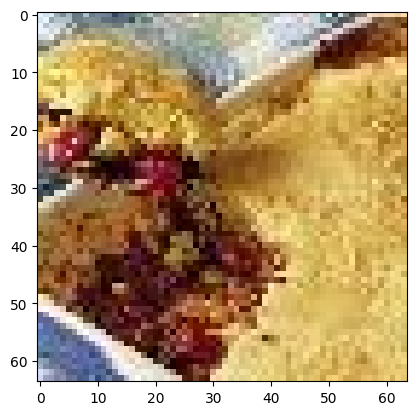

In [29]:
plt.imshow(img)

In [37]:
path = 'tiny-imagenet-200/test/images/test_2.JPEG'

In [38]:
img = plt.imread(path)

In [39]:
model.predict(np.expand_dims(tf.keras.utils.img_to_array(tf.keras.utils.load_img(path, target_size=IMG_SIZE)), axis=0)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([44])

In [42]:
keys = list(wnid_to_name.keys()) 
target_key = keys[44]  
print(wnid_to_name[target_key])

monarch, monarch butterfly, milkweed butterfly, Danaus plexippus


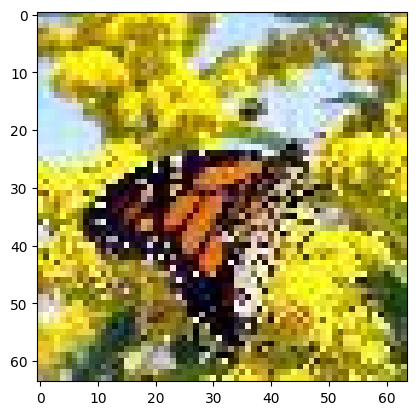

In [41]:
plt.imshow(img)